Load dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_excel("Flight_Fare.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


Dataset Understand

In [12]:
df.shape

(10683, 11)

In [13]:
df.info

<bound method DataFrame.info of            Airline Date_of_Journey    Source Destination  \
0           IndiGo      24/03/2019  Banglore   New Delhi   
1        Air India       1/05/2019   Kolkata    Banglore   
2      Jet Airways       9/06/2019     Delhi      Cochin   
3           IndiGo      12/05/2019   Kolkata    Banglore   
4           IndiGo      01/03/2019  Banglore   New Delhi   
...            ...             ...       ...         ...   
10678     Air Asia       9/04/2019   Kolkata    Banglore   
10679    Air India      27/04/2019   Kolkata    Banglore   
10680  Jet Airways      27/04/2019  Banglore       Delhi   
10681      Vistara      01/03/2019  Banglore   New Delhi   
10682    Air India       9/05/2019     Delhi      Cochin   

                       Route Dep_Time  Arrival_Time Duration Total_Stops  \
0                  BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop   
1      CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops   
2      DEL → LKO → 

In [14]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [15]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

Checking Missing Values

In [16]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [17]:
df=df.dropna()
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

Check Duplicate Data

In [18]:
df.duplicated().sum()

np.int64(220)

In [19]:
df=df.drop_duplicates()
print(df.shape)

(10462, 11)


Analyze Flight Prices

In [20]:
df["Price"].describe()

count    10462.000000
mean      9026.790289
std       4624.849541
min       1759.000000
25%       5224.000000
50%       8266.000000
75%      12344.750000
max      79512.000000
Name: Price, dtype: float64

In [21]:
df["Price"].min()

np.int64(1759)

In [22]:
df["Price"].max()

np.int64(79512)

In [23]:
df["Price"].mean()

np.float64(9026.790288663735)

Flight Price Distribution

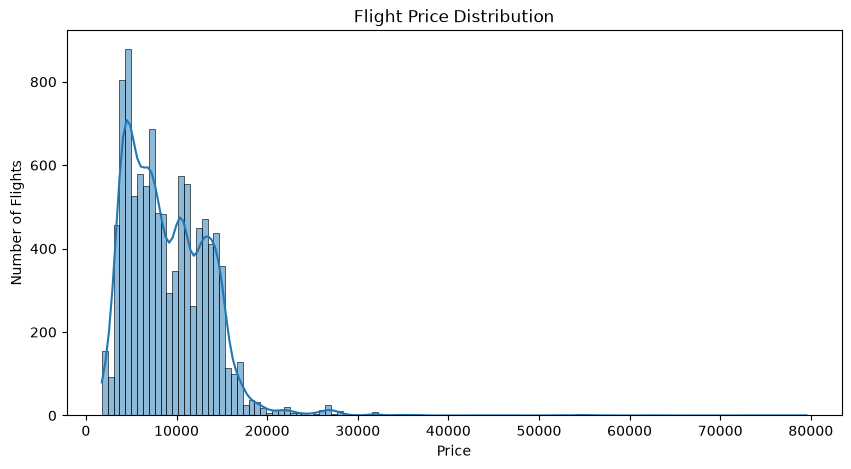

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df["Price"], kde=True)
plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Flights")
plt.show()

Airline vs Flight Price

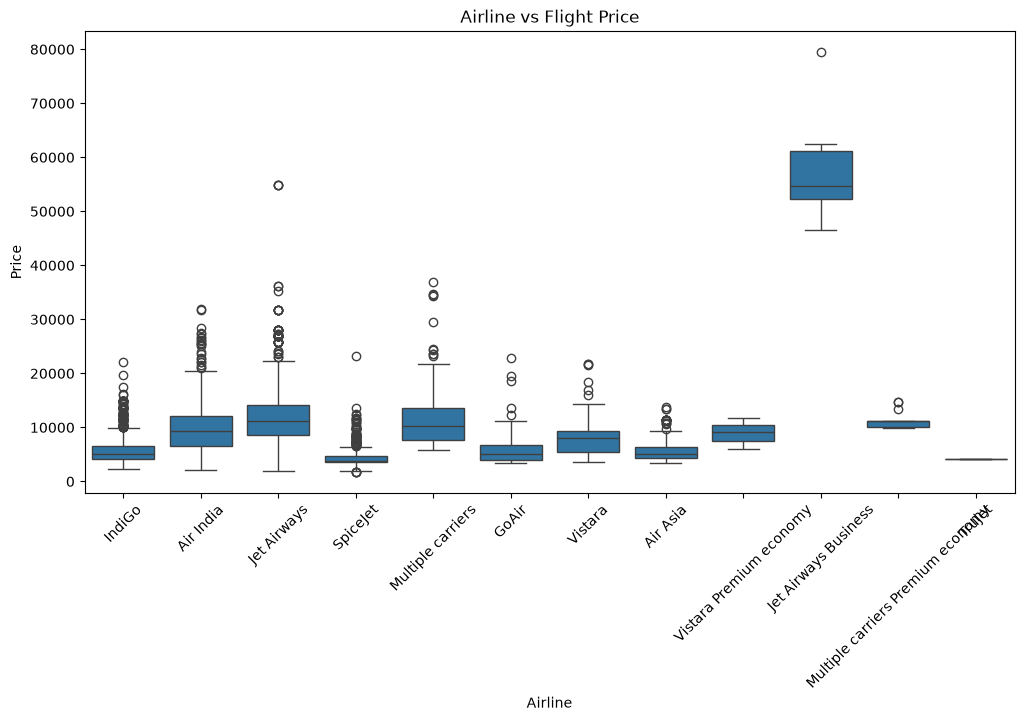

In [29]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Airline", y="Price")
plt.xticks(rotation=45)
plt.title("Airline vs Flight Price")
plt.show()

In [33]:
df.groupby("Airline")["Price"].mean().sort_values(ascending=False)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64

Source vs Price

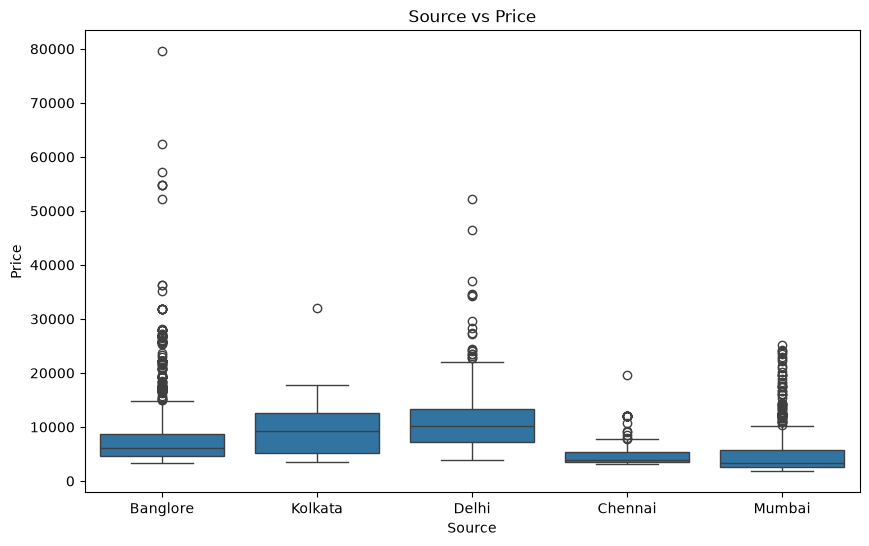

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Source",y="Price")
plt.title("Source vs Price")
plt.show()

Destination vs Price

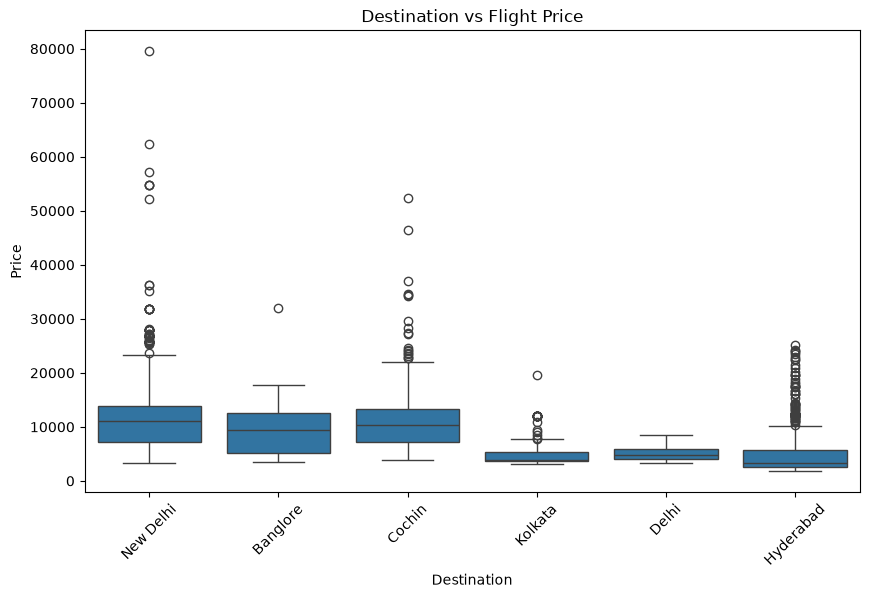

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Destination",y="Price")
plt.xticks(rotation=45)
plt.title("Destination vs Flight Price")
plt.show()

Number of stops vs Price

In [44]:
df.groupby("Total_Stops")["Price"].mean().sort_values()

Total_Stops
non-stop     5018.506763
1 stop      10594.123556
2 stops     12761.099393
3 stops     13260.674419
4 stops     17686.000000
Name: Price, dtype: float64

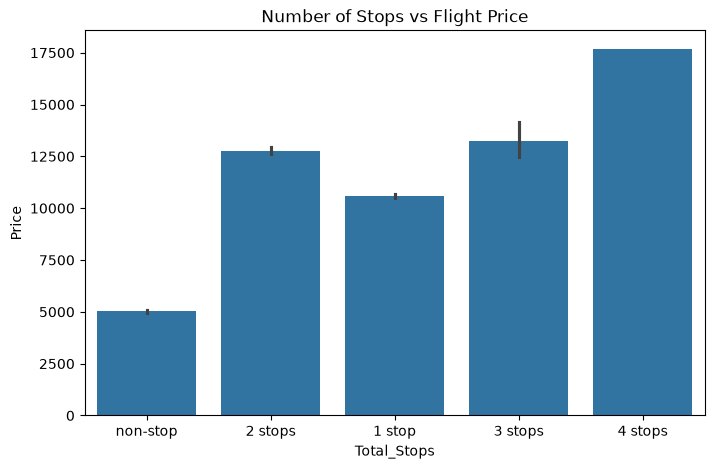

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Total_Stops",y="Price")
plt.title("Number of Stops vs Flight Price")
plt.show()

Feature Engineering

In [47]:
df["Date_of_Journey"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
)

In [48]:
df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month

In [49]:
df[["Date_of_Journey", "Journey_Day", "Journey_Month"]].head()

,Date_of_Journey,Journey_Day,Journey_Month
0,2019-03-24,24,3
1,2019-05-01,1,5
2,2019-06-09,9,6
3,2019-05-12,12,5
4,2019-03-01,1,3


Convert Duration into minutes

In [54]:
def duration_to_minutes(duration):
    hours = 0
    minutes = 0
    
    if "h" in duration:
        hours = int(duration.split("h")[0])
        
    if "m" in duration:
        minutes_part = duration.split("h")[-1].replace("m", "").strip()
        if minutes_part:
            minutes = int(minutes_part)
            
    return hours * 60 + minutes

In [55]:
df["Duration_Minutes"] = df["Duration"].apply(duration_to_minutes)

In [56]:
df[["Duration", "Duration_Minutes"]].head()

,Duration,Duration_Minutes
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285


Convert total stops

In [57]:
stop_mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}

df["Total_Stops"] = df["Total_Stops"].map(stop_mapping)

In [58]:
df["Total_Stops"].value_counts()

Total_Stops
1    5625
0    3475
2    1318
3      43
4       1
Name: count, dtype: int64

Data for Machine Learning

In [59]:
df = df.drop([
    "Date_of_Journey",
    "Route",
    "Dep_Time",
    "Arrival_Time",
    "Duration"
], axis=1)

In [60]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Data_of_Journey,Journey_Day,Journey_Month,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,No info,3897,2019-03-24,24,3,170
1,Air India,Kolkata,Banglore,2,No info,7662,2019-05-01,1,5,445
2,Jet Airways,Delhi,Cochin,2,No info,13882,2019-06-09,9,6,1140
3,IndiGo,Kolkata,Banglore,1,No info,6218,2019-05-12,12,5,325
4,IndiGo,Banglore,New Delhi,1,No info,13302,2019-03-01,1,3,285


Convert categorical columns into numberrs

In [62]:
df=pd.get_dummies(df,drop_first=True)

In [63]:
df.head()

,Total_Stops,Price,Data_of_Journey,Journey_Day,Journey_Month,Duration_Minutes,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,3897,2019-03-24,24,3,170,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,2,7662,2019-05-01,1,5,445,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2,13882,2019-06-09,9,6,1140,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,1,6218,2019-05-12,12,5,325,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,1,13302,2019-03-01,1,3,285,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False


Separate X and Y

In [64]:
x=df.drop("Price",axis=1)
y=df["Price"]

In [65]:
print(x.shape)
print(y.shape)

(10462, 34)
(10462,)


Split training and testing data

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (8369, 34)
Testing data: (2093, 34)


Train Random forest

In [72]:
print(x_train.dtypes)

Total_Stops                                              int64
Data_of_Journey                                 datetime64[us]
Journey_Day                                              int32
Journey_Month                                            int32
Duration_Minutes                                         int64
Airline_Air India                                         bool
Airline_GoAir                                             bool
Airline_IndiGo                                            bool
Airline_Jet Airways                                       bool
Airline_Jet Airways Business                              bool
Airline_Multiple carriers                                 bool
Airline_Multiple carriers Premium economy                 bool
Airline_SpiceJet                                          bool
Airline_Trujet                                            bool
Airline_Vistara                                           bool
Airline_Vistara Premium economy                        

In [73]:
print(x_train.select_dtypes(exclude='number').columns)

Index(['Data_of_Journey', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Short layover', 'Additional_Info_2 Long layover',
       'Additional_Info_Business class', 'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye flight'],
      dtype='str')


In [85]:
x = pd.get_dummies(x, drop_first=True)

In [86]:
X = df.drop("Price", axis=1)
y = df["Price"]
X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)
y = pd.to_numeric(y, errors="coerce")
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10462, 34)
y shape: (10462,)


In [88]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (8369, 34)
Testing data: (2093, 34)


In [93]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Predict Flight Prices

In [95]:
y_pred = rf.predict(x_test)

In [96]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,17996,16748.40000
1,3873,3904.23600
2,4462,4418.28981
3,2228,2414.41550
4,4991,4387.83000
5,7670,7743.82000
6,14086,17613.13000
7,6386,6216.61350
8,6628,6724.88000
9,6934,6443.91500


Evaluate your model

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 904.2999553038038
MSE: 3419516.3737105676
RMSE: 1849.19343869444
R2 Score: 0.8359965924800046


In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [102]:
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)  
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [104]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)
results_df.sort_values(
    "R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,904.299955,1849.193439,0.835997
3,Gradient Boosting,1241.695846,1989.486736,0.810168
1,Decision Tree,1004.810342,2216.275558,0.764421
0,Linear Regression,3645.670100,4500.179758,0.028712


PROJECT FLOW

FLIGHT FARE PREDICTION
        ↓
Load Excel Dataset
        ↓
Data Understanding
        ↓
Missing Value Handling
        ↓
Duplicate Checking
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
Categorical Encoding
        ↓
Train/Test Split
        ↓
Model Training
        ↓
Model Comparison
        ↓
Prediction
        ↓
Model Evaluation
        ↓
Final Conclusion